## 1. Import required Libraries

In [28]:
import pandas as pd
#for data loading,cleaning,analysis.

import numpy as np
#for arrays and mathematical operations

import matplotlib.pyplot as plt
import seaborn as sns
#used for plotting charts

from sklearn.model_selection import train_test_split
#to split your dataset into training and testing sets.


from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
#To evaluate ML model

from catboost import CatBoostClassifier, Pool
from joblib import dump

## 2. Load Data

In [29]:
df=pd.read_csv("data/e-commerce2.csv")

In [30]:
df.head()

,ROW ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Quantity,Discount,Shipping Cost,Profit,Order Priority,Year,Month,Day,Delivery Time,Cost
0,34323,CA-2012-124891,2012-07-31,2012-07-31,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,7,0.0,933.57,762.1845,Critical,2012,7,Tuesday,0,613.8955
1,26341,IN-2013-77878,2013-02-05,2013-02-07,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,9,0.1,923.63,-288.7650,Critical,2013,2,Tuesday,2,3074.5300
2,25330,IN-2013-71249,2013-10-17,2013-10-18,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,9,0.1,915.49,919.9710,Medium,2013,10,Thursday,1,3339.7100
3,13524,ES-2013-1579342,2013-01-28,2013-01-30,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,5,0.1,910.16,-96.5400,Medium,2013,1,Monday,2,2078.8900
4,47221,SG-2013-4320,2013-11-05,2013-11-06,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,8,0.0,903.04,311.5200,Critical,2013,11,Tuesday,1,1618.4000


## 3. Data Cleaning

In [31]:
#Below mentioned coluns are non-informative features.
#Dropping them because they are unique identifiers or text labels that do not contribute to predicting Order Priority.
#Keeping them would Increase computation,Reduce accuracy or Cause overfitting.

In [32]:
# df = df.drop(["ROW ID", "Order ID", "Customer ID", "Customer Name",
#               "Product ID", "Product Name"], axis=1)

In [33]:
df.columns

Index(['ROW ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Market', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Shipping Cost',
       'Profit', 'Order Priority', 'Year', 'Month', 'Day', 'Delivery Time',
       'Cost'],
      dtype='object')

## 4. Label Encode the Target

In [34]:
#Encoding categorical columns because ML models cannot understand text as they only work with numbers.

## 5. Encode Categorical Features

## 6. Split Features (X) & Target (y)

In [42]:
#Dropping Order Priority as it is a target column(y)
X = df.drop("Order Priority", axis=1)
X.columns

Index(['ROW ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Market', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Shipping Cost',
       'Profit', 'Year', 'Month', 'Day', 'Delivery Time', 'Cost'],
      dtype='object')

In [43]:
y = df["Order Priority"]
y.head()

0    Critical
1    Critical
2      Medium
3      Medium
4    Critical
Name: Order Priority, dtype: object

In [44]:
cat_cols = X.select_dtypes(include=["object", "string"]).columns.tolist()

In [45]:
dump(cat_cols, "model/cat_cols.joblib")

['cat_cols.joblib']

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [47]:
y_train

29777    Medium
44297       Low
43109    Medium
5207        Low
23539    Medium
          ...  
41417    Medium
32601    Medium
5517     Medium
49740    Medium
51112    Medium
Name: Order Priority, Length: 41032, dtype: object

## 7. Train the Machine Learning Model

In [52]:
# Create CatBoost Pools
train_pool = Pool(X_train, y_train, cat_features=cat_cols)
test_pool = Pool(X_test, y_test, cat_features=cat_cols)

In [54]:
model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    loss_function="MultiClass",
    eval_metric="Accuracy",
    random_seed=42,
    verbose=100
)

model.fit(train_pool, eval_set=test_pool)

# model = CatBoostClassifier(
#     iterations=500,
#     learning_rate=0.05,
#     depth=8,
#     loss_function='MultiClass',
#     eval_metric='Accuracy',
#     verbose=100
# )

# model.fit(
#     X_train,
#     y_train,
#     cat_features=cat_cols,
#     eval_set=(X_test, y_test),
#     use_best_model=True
# )

0:	learn: 0.6366982	test: 0.6327744	best: 0.6327744 (0)	total: 1.37s	remaining: 11m 23s
100:	learn: 0.8472655	test: 0.9100214	best: 0.9102164 (99)	total: 2m 8s	remaining: 8m 28s
200:	learn: 0.8677374	test: 0.9174303	best: 0.9179177 (195)	total: 4m 22s	remaining: 6m 30s
300:	learn: 0.8764135	test: 0.9190875	best: 0.9196725 (278)	total: 6m 37s	remaining: 4m 22s
400:	learn: 0.8835299	test: 0.9186976	best: 0.9196725 (278)	total: 8m 51s	remaining: 2m 11s
499:	learn: 0.8875024	test: 0.9190875	best: 0.9196725 (278)	total: 11m 4s	remaining: 0us

bestTest = 0.9196724508
bestIteration = 278

Shrink model to first 279 iterations.


CatBoostClassifier(depth=6, eval_metric='Accuracy', iterations=500, learning_rate=0.1, loss_function='MultiClass', random_seed=42, verbose=100)

## 8. Evaluate the Model Performance

In [55]:
y_pred = model.predict(X_test)

In [56]:
y_pred

array([['High'],
       ['Medium'],
       ['High'],
       ...,
       ['High'],
       ['Critical'],
       ['High']], shape=(10258, 1), dtype=object)

In [57]:
y_pred=y_pred.flatten()
y_pred

array(['High', 'Medium', 'High', ..., 'High', 'Critical', 'High'],
      shape=(10258,), dtype=object)

In [58]:
# side by side comparison of actual value and predicted value
comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred.flatten()
})

comparison_df.head()

,Actual,Predicted
9984,Medium,High
43403,Medium,Medium
36221,Medium,High
38579,Medium,Medium
24366,Medium,Medium


In [59]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9196724507701306

Classification Report:
               precision    recall  f1-score   support

    Critical       0.94      0.83      0.88       786
        High       0.88      0.89      0.88      3100
         Low       0.96      0.86      0.90       485
      Medium       0.94      0.95      0.94      5887

    accuracy                           0.92     10258
   macro avg       0.93      0.88      0.90     10258
weighted avg       0.92      0.92      0.92     10258



## 10. Feature Importance

In [60]:
#Feature importances gives the importance score of each input feature used by the Random Forest.
#Shows which features contribute most to predicting the target (Order Priority).

In [61]:
importances = model.feature_importances_
importances

array([5.87965782e-02, 3.13462433e+01, 4.05124483e-01, 2.67734919e+00,
       1.36531034e+01, 3.18749696e-01, 3.35102717e-01, 2.49288626e-01,
       2.00553234e-01, 2.81044789e-01, 1.51923499e-01, 3.52961811e-01,
       2.95383279e-01, 0.00000000e+00, 2.28560148e-01, 3.31073460e-01,
       6.26445247e-02, 6.14669726e+00, 7.54000129e-02, 4.18836164e-01,
       1.15546350e+01, 9.43570520e-01, 2.72162250e-02, 1.70194495e-02,
       2.54175345e-01, 2.61189243e+01, 3.49562300e+00])

In [62]:
feature_names = X.columns
feature_names

Index(['ROW ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Market', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Shipping Cost',
       'Profit', 'Year', 'Month', 'Day', 'Delivery Time', 'Cost'],
      dtype='object')

In [63]:
type(importances)

numpy.ndarray

In [64]:
type(feature_names)

pandas.core.indexes.base.Index

In [65]:
# Convert feature names and importances into numpy arrays as both of them are of diffrent datatypes.
# Make their datatype even and prevent any mismatch error.
# Sorting becomes easier and also Matplotlib works best with NumPy arrays.
importances = np.array(importances)
feature_names = np.array(feature_names)

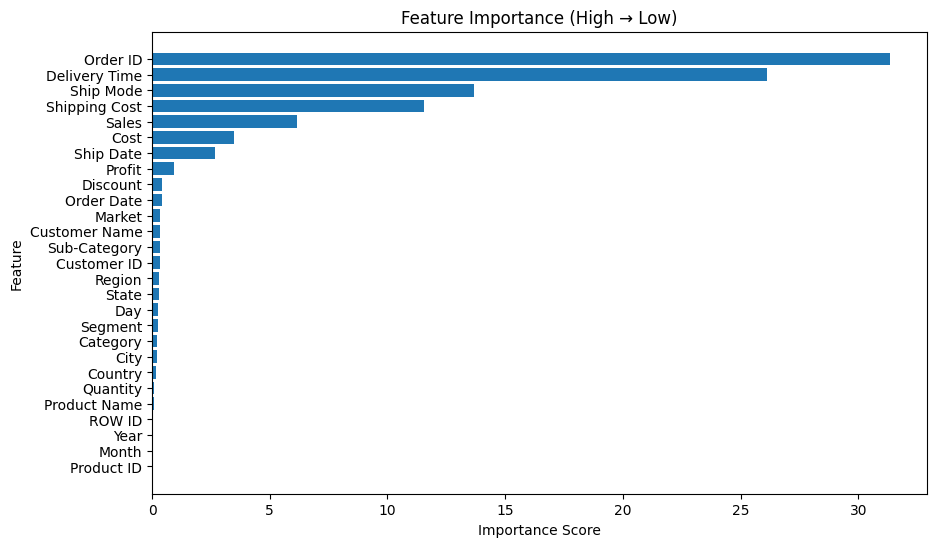

In [66]:
# Sort importances in descending order
sorted_idx = np.argsort(importances)[::-1]

# Sort both arrays
sorted_importances = importances[sorted_idx]
sorted_features = feature_names[sorted_idx]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.title("Feature Importance (High → Low)")
plt.gca().invert_yaxis()   # Highest at top
plt.show()

In [67]:
#Based on the Graph, Delivery Time is the strongest predictor.

In [68]:
# Calculate percentage contribution
percent_importance = (importances / importances.sum()) * 100

# Create DataFrame
feature_table = pd.DataFrame({
    "Feature": feature_names,
    "Importance (%)": percent_importance
})

# Sort highest → lowest
feature_table = feature_table.sort_values(by="Importance (%)", ascending=False)

# Round values
feature_table["Importance (%)"] = feature_table["Importance (%)"].round(2)

# Display table
feature_table.head()

,Feature,Importance (%)
1,Order ID,31.35
25,Delivery Time,26.12
4,Ship Mode,13.65
20,Shipping Cost,11.55
17,Sales,6.15


## 11. Model Evaluation through Visuals

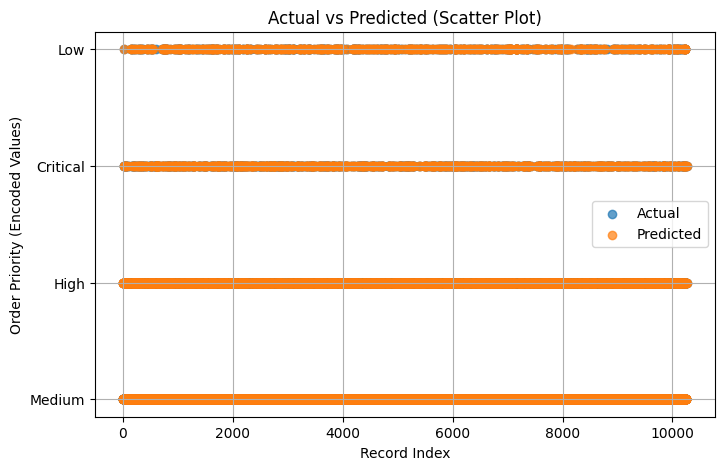

In [69]:
plt.figure(figsize=(8, 5))
plt.scatter(range(len(y_test)), y_test, label="Actual", alpha=0.7)
plt.scatter(range(len(y_pred)), y_pred, label="Predicted", alpha=0.7)
plt.xlabel("Record Index")
plt.ylabel("Order Priority (Encoded Values)")
plt.title("Actual vs Predicted (Scatter Plot)")
plt.legend()
plt.grid(True)
plt.show()

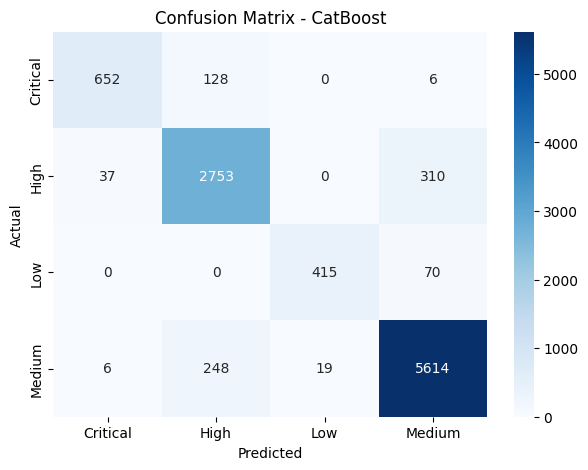

In [70]:
# Get sorted unique labels
labels = sorted(y_test.unique())  # ensures correct label order

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)

# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)
plt.title("Confusion Matrix - CatBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

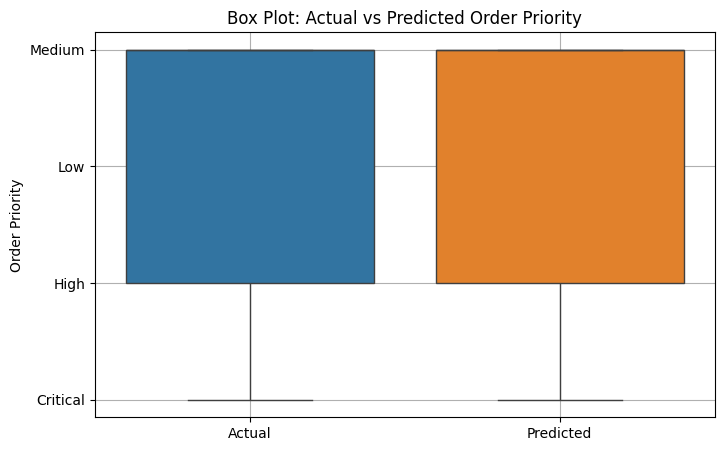

In [73]:
# Convert string labels to category → numeric codes
actual_cat = y_test.astype("category")
pred_cat = pd.Series(y_pred).astype("category")

df_box = pd.DataFrame({
    "Actual": actual_cat.cat.codes,
    "Predicted": pred_cat.cat.codes
})

plt.figure(figsize=(8,5))
sns.boxplot(data=df_box)

# Replace numeric ticks with original labels
labels = list(actual_cat.cat.categories)
plt.xticks([0,1], ["Actual", "Predicted"])
plt.yticks(range(len(labels)), labels)

plt.title("Box Plot: Actual vs Predicted Order Priority")
plt.ylabel("Order Priority")
plt.grid(True)
plt.show()

## 12. Save Model

In [74]:
# import joblib
# joblib.dump(model, "order_priority_model.pkl")
# joblib.dump(le, "order_priority_encoder.pkl")

In [75]:
# joblib.dump(model, "order_priority_model.joblib")
# print("Model saved successfully!")

In [76]:
model.save_model("model/order_priority_model.cbm")
print("Model saved successfully!")

Model saved successfully!


## 13. Load Model

In [77]:
# model = joblib.load("order_priority_model.pkl")
# le = joblib.load("order_priority_encoder.pkl")